## Extended Kalman Filter Examples

### Exemple II: Joint State-Parameter Estimation

In [3]:
import numpy as np
import scipy.signal as sig
import scipy.linalg as lin
import matplotlib.pyplot as plt

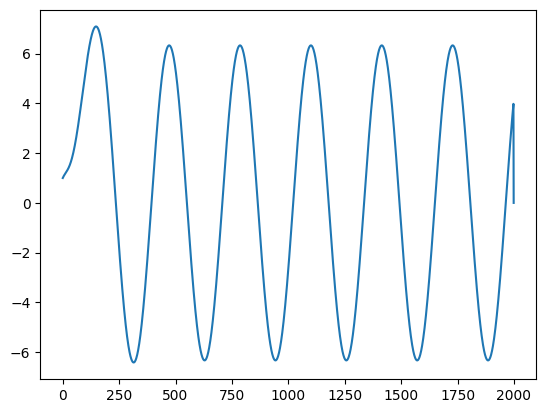

In [4]:
# Parameter
from sympy import N


zeta = 0.8
omega = 1

A = np.array([[0, 1], [-omega**2, -2*zeta*omega]])
B = np.array([[0], [omega**2]])
C = np.array([[1, 0]])

dt = 0.02
Ad = np.eye(2) + A*dt
Bd = B*dt
Cd = C


nx = 2
nu = 1
ny = 1

N = 2000
times = np.arange(N)

x = np.zeros((nx, N))
y = np.zeros((ny, N))
u = np.zeros((nu, N))  
v = np.zeros((ny, N))
w = np.zeros((nx, N))

x[:,0] = np.array([1, 1])

for k in range(N-1):
    u[:,k] = 10*np.sin(k*dt)
    y[:,k] = Cd@x[:,k] 
    x[:,k+1] = Ad @ x[:,k] + Bd @u[:,k]

plt.figure()
plt.plot(times, y.squeeze(), label='x1')
# print(y.squeeze().shape)
# print(times.shape)
# print(u.shape)
# print(x.shape)



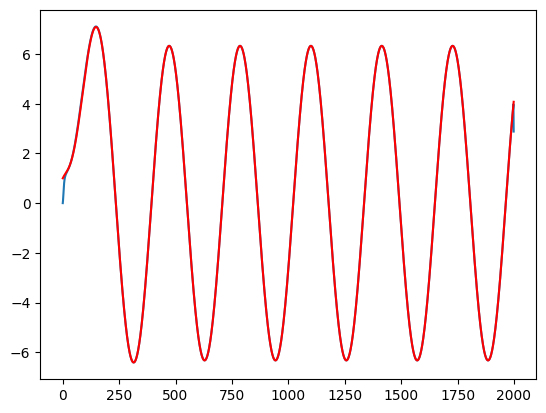

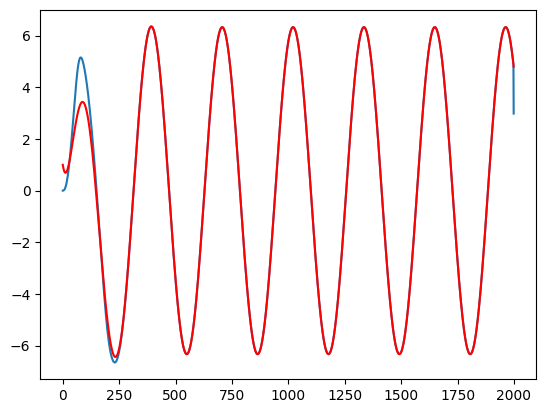

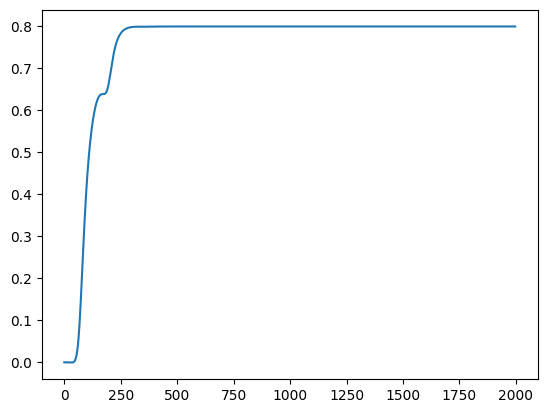

In [ ]:
# Esimation

xhat = np.zeros((nx+1, N))
P = np.zeros((nx+1, nx+1, N))

meanNoiseVar = 1
R = meanNoiseVar * np.eye(ny)
Q = 0.1 * np.eye(nx+1)
Q[2, 2] = 0.01


for k in range(N-1):
    xhat[:,k]
    PCur = P[:,:,k]
    # Prediction
    F = np.array([[1, dt, 0], [-dt, 1 - 2 * xhat[2,k] * dt, -2 * xhat[1,k] * dt], [0, 0, 1]])
    xhatPred = xhat[:,k] + np.array([[xhat[1,k] * dt], [-xhat[0,k] *dt - 2 * xhat[1,k] * xhat[2,k]*dt + u[0, k]*dt], [0]]).squeeze()
    PPred = F @ PCur @ F.T + Q

    # Measurement update
    ymeas = y[:,k+1]
    H = np.array([[1, 0, 0]])
    hWithoutNoise = h
    Kgain = PPred @ H.T @ lin.inv(H @ PPred @ H.T + R)
    xhatNext = xhatPred + Kgain @ (ymeas - hWithoutNoise)
    PNext = (np.eye(nx+1) - Kgain @ H) @ PPred

    # Assign results
    xhat[:,k+1] = xhatNext
    P[:,:,k+1] = PNext

plt.figure(1)
plt.plot(times, xhat[0,:].T)
plt.plot(times, x[0,:].T, 'r')
plt.figure(2)
plt.plot(times, xhat[1,:].T)
plt.plot(times, x[1,:].T, 'r')

plt.figure(3)
plt.plot(times[0:-2], xhat[2,0:-2].T)




